# SARSA on FrozenLake

**SARSA** (State-Action-Reward-State-Action) is a model-free, **on-policy** reinforcement learning algorithm. Like Q-Learning, it learns an action-value function $Q(s, a)$ from experience — but the key difference is *which* next action it uses to bootstrap the update.

The update rule is:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma\, Q(s', a') - Q(s, a) \right]$$

Where $a'$ is the action **actually selected** for the next state $s'$ by the same $\varepsilon$-greedy policy the agent is following — not the greedy $\max_{a'} Q(s', a')$ used by Q-Learning.

### SARSA vs. Q-Learning

| | SARSA | Q-Learning |
|---|---|---|
| Policy type | On-policy | Off-policy |
| Next-action used in update | $a'$ actually taken (epsilon-greedy) | $\max_{a'} Q(s', a')$ (greedy, regardless of behaviour) |
| Behaviour | Learns the value of the policy it is actually following, including its exploratory mistakes | Learns the value of the optimal policy, even while exploring |
| Typical effect | Tends to learn more "cautious" policies near risky states, since exploration mistakes are factored into the value | Tends to learn more aggressive/optimal policies, since exploration noise doesn't pollute the target |

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random

## Implementation

In [ ]:
def sarsa(
    env: gym.Env,
    alpha: float = 0.1,
    gamma: float = 0.90,
    epsilon: float = 0.1,
    episodes: int = 10000,
    max_steps: int = 100,
) -> tuple[np.ndarray, np.ndarray]:
    """Train an agent using the tabular SARSA algorithm.

    SARSA (State-Action-Reward-State-Action) is an on-policy TD control
    method: it updates Q(s, a) using the action *actually taken* in the next
    state (sampled from the same epsilon-greedy policy used for behaviour),
    rather than the greedy max as in Q-Learning. This makes the learned
    policy account for the exploration the agent performs during training.

    Args:
        env: A Gymnasium discrete environment with `observation_space.n`
             states and `action_space.n` actions.
        alpha: Learning rate — how much each new TD estimate overwrites the
               current Q value (0 < alpha <= 1).
        gamma: Discount factor — weight given to future rewards vs. immediate
               ones (0 <= gamma <= 1).
        epsilon: Initial exploration probability for the epsilon-greedy policy.
                 Decayed linearly toward 0.01 over episodes.
        episodes: Number of training episodes.
        max_steps: Maximum number of steps allowed per episode.

    Returns:
        Q: The learned Q-table of shape (n_states, n_actions).
        policy: Greedy policy array of shape (n_states,) where each entry is
                the action with the highest Q value for that state.
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Q-table initialised to zero: agent starts with no prior knowledge
    Q: np.ndarray = np.zeros((n_states, n_actions))

    for episode in range(episodes):

        # Linearly decay epsilon so the agent exploits more as it learns
        epsilon = max(0.01, epsilon - 0.01)

        # Reset the environment and get the starting state for this episode
        state, _ = env.reset()

        # --- Choose the first action via epsilon-greedy (on-policy) ---
        # SARSA needs an action selected for the starting state up front,
        # since each step updates Q using the *next* action it will take.
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state, :])

        for step in range(max_steps):
            next_state, reward, done, _, _ = env.step(action)

            # Penalise falling into a hole or reaching a terminal failure state
            if done and reward <= 0:
                reward = -1

            # Penalise standing still to discourage the agent from getting stuck
            if state == next_state:
                reward -= 1

            # --- Epsilon-greedy selection of the NEXT action ---
            # This is what makes SARSA on-policy: the same exploratory
            # policy used to act is also used to estimate the next value.
            if random.uniform(0, 1) < epsilon:
                next_action = env.action_space.sample()
            else:
                next_action = np.argmax(Q[next_state, :])

            # --- SARSA update rule (TD(0), on-policy) ---
            # Unlike Q-Learning's max over next actions, SARSA bootstraps
            # using the actual next_action that will be taken.
            Q[state, action] += alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state = next_state
            action = next_action

            if done:
                print(f"Episode {episode} finished after {step + 1} step(s)")
                break

    # Derive a deterministic greedy policy from the final Q-table
    policy: np.ndarray = np.argmax(Q, axis=1)

    return Q, policy

## Environment — FrozenLake-v1

[FrozenLake-v1](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) is a 4×4 grid-world where the agent must navigate from the **Start** (S) tile to the **Goal** (G) tile without stepping on any **Hole** (H). Safe tiles are **Frozen** (F).

```
S F F F
F H F H
F F F H
H F F G
```

| Symbol | Meaning |
|--------|---------|
| S | Start — initial agent position |
| F | Frozen — safe to walk on |
| H | Hole — episode ends, reward = 0 |
| G | Goal — episode ends, reward = 1 |

**State space:** 16 discrete positions (one per tile).  
**Action space:** 4 discrete actions — Left (0), Down (1), Right (2), Up (3).  
**`is_slippery=False`** removes stochastic wind, making transitions fully deterministic and easier to solve.

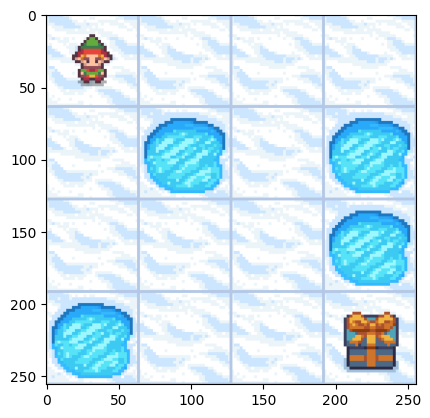

In [6]:
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')
env.reset()
frame = env.render()
plt.imshow(frame);

## Training

The agent is trained for 1000 episodes. Compared to a naive setup, the hyperparameters below give the agent enough time to explore before exploitation takes over:

- **Lower starting `epsilon` (0.2)** combined with a slow linear decay (−0.01/episode) and a **larger episode budget (1000)** ensures the agent spends a meaningful fraction of training exploring randomly before settling into a near-greedy policy — important so it has a real chance to stumble onto the goal and propagate a reward signal backward through the Q-table.
- **Hole penalty** (`reward = -1`): the default reward on failure is 0, which gives the agent no signal to avoid holes. Replacing it with −1 makes bad outcomes distinguishable from neutral ones.
- **Idle penalty** (`reward -= 1`): if the agent tries to walk into a wall and stays in the same state, it is penalised to prevent it from standing still.

| Hyperparameter | Value | Role |
|---|---|---|
| `alpha` | 0.9 | High learning rate — fast updates, suitable for a deterministic environment |
| `gamma` | 0.99 | Near-1 discount — the agent cares almost as much about future rewards as immediate ones |
| `epsilon` | 0.2 (→ 0.01) | Starts with moderate exploration; decays linearly by 0.01 each episode |
| `episodes` | 1000 | Total training episodes — large enough for exploration to find the goal before epsilon bottoms out |
| `max_steps` | 100 | Hard cap per episode to prevent infinite loops |

In [8]:
alpha = 0.9     # Learning rate
gamma = 0.99    # Discount factor
epsilon = 0.2   # Exploration rate (decays linearly during training)
episodes = 1000
max_steps = 100

Q, policy = sarsa(env, alpha, gamma, epsilon, episodes, max_steps)

print("Q-Table:")
print(Q)
print("\nDerived Policy (0=Left, 1=Down, 2=Right, 3=Up):")
print(policy.reshape((4, 4)))

Episode 0 finished after 6 step(s)
Episode 1 finished after 42 step(s)
Episode 2 finished after 18 step(s)
Episode 3 finished after 39 step(s)
Episode 4 finished after 2 step(s)
Episode 5 finished after 8 step(s)
Episode 6 finished after 4 step(s)
Episode 7 finished after 34 step(s)
Episode 8 finished after 6 step(s)
Episode 9 finished after 6 step(s)
Episode 10 finished after 6 step(s)
Episode 11 finished after 7 step(s)
Episode 12 finished after 6 step(s)
Episode 13 finished after 6 step(s)
Episode 14 finished after 6 step(s)
Episode 15 finished after 6 step(s)
Episode 16 finished after 6 step(s)
Episode 17 finished after 6 step(s)
Episode 18 finished after 6 step(s)
Episode 19 finished after 6 step(s)
Episode 20 finished after 6 step(s)
Episode 21 finished after 6 step(s)
Episode 22 finished after 6 step(s)
Episode 23 finished after 6 step(s)
Episode 24 finished after 6 step(s)
Episode 25 finished after 6 step(s)
Episode 26 finished after 6 step(s)
Episode 27 finished after 6 step(s

## Results

After training, the Q-table holds an on-policy value estimate for every (state, action) pair. Taking `argmax` over actions for each state produces the **greedy policy** — the action the agent considers best from each tile.

For states along the path the agent actually traverses during training, the Q-values converge to the textbook discounted-return pattern: $Q(s, a) \approx \gamma^{k}$, where $k$ is the number of steps from that state to the goal. States that are rarely or never visited under the (increasingly greedy) behaviour policy may retain noisy or unconverged values — this is expected with on-policy learning and limited exploration, not a bug.

The policy is reshaped into a 4×4 grid matching the FrozenLake layout. The trained policy above routes the agent from tile (0,0) to tile (3,3) while avoiding all holes along that path:

```
→  →  ↓  ←
↓  ←  ↓  ←   (H tiles — actions here are irrelevant)
→  →  ↓  ←   (H tile — action is irrelevant)
←  →  →  ←   (H/G tiles — actions here are irrelevant)
```